In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#configuration for plots
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

In [2]:
df = pd.read_csv('data/data.csv')
#initial visualization
display(df.head())
print(f"\nDataset dimensions: {df.shape[0]:,} rows and {df.shape[1]} columns.")

#Null values summary
print("\nNull values per column:")
print(df.isnull().sum())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Dataset dimensions: 6,362,620 rows and 11 columns.

Null values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [4]:
#verify that fraud only happens in TRANSFER and CASH_OUT
print("Original fraud distribution by transaction type:")
print(df[df['isFraud'] == 1]['type'].value_counts())

#vectorizing the multi-class target creation for computational efficiency
conditions = [
    (df['isFraud'] == 0),
    (df['isFraud'] == 1) & (df['type'] == 'TRANSFER'),
    (df['isFraud'] == 1) & (df['type'] == 'CASH_OUT')
]

choices = [0, 1, 2]

#apply conditions
df['fraud_type'] = np.select(conditions, choices, default=0)

print("\nNew variable 'fraud_type' successfully created.")

Original fraud distribution by transaction type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

New variable 'fraud_type' successfully created.


,Absolute,Percentage (%)
fraud_type,,
0,6354407,99.870918
2,4116,0.064690
1,4097,0.064392


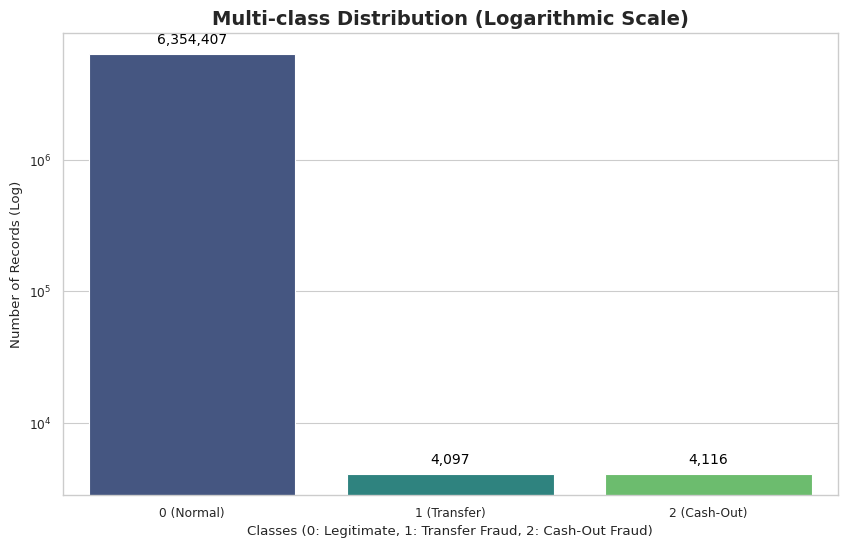

In [5]:
#absolute and relative frequencies
target_counts = df['fraud_type'].value_counts()
target_pct = df['fraud_type'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({'Absolute': target_counts, 'Percentage (%)': target_pct})
display(summary_target)

#logarithmic scale plot (Mandatory to even see classes 1 and 2)
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='fraud_type', palette='viridis', ax=ax)

#apply logarithm on the Y-axis
ax.set_yscale('log')
ax.set_title('Multi-class Distribution (Logarithmic Scale)')
ax.set_ylabel('Number of Records (Log)')
ax.set_xlabel('Classes (0: Legitimate, 1: Transfer Fraud, 2: Cash-Out Fraud)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['0 (Normal)', '1 (Transfer)', '2 (Cash-Out)'])

#add text labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

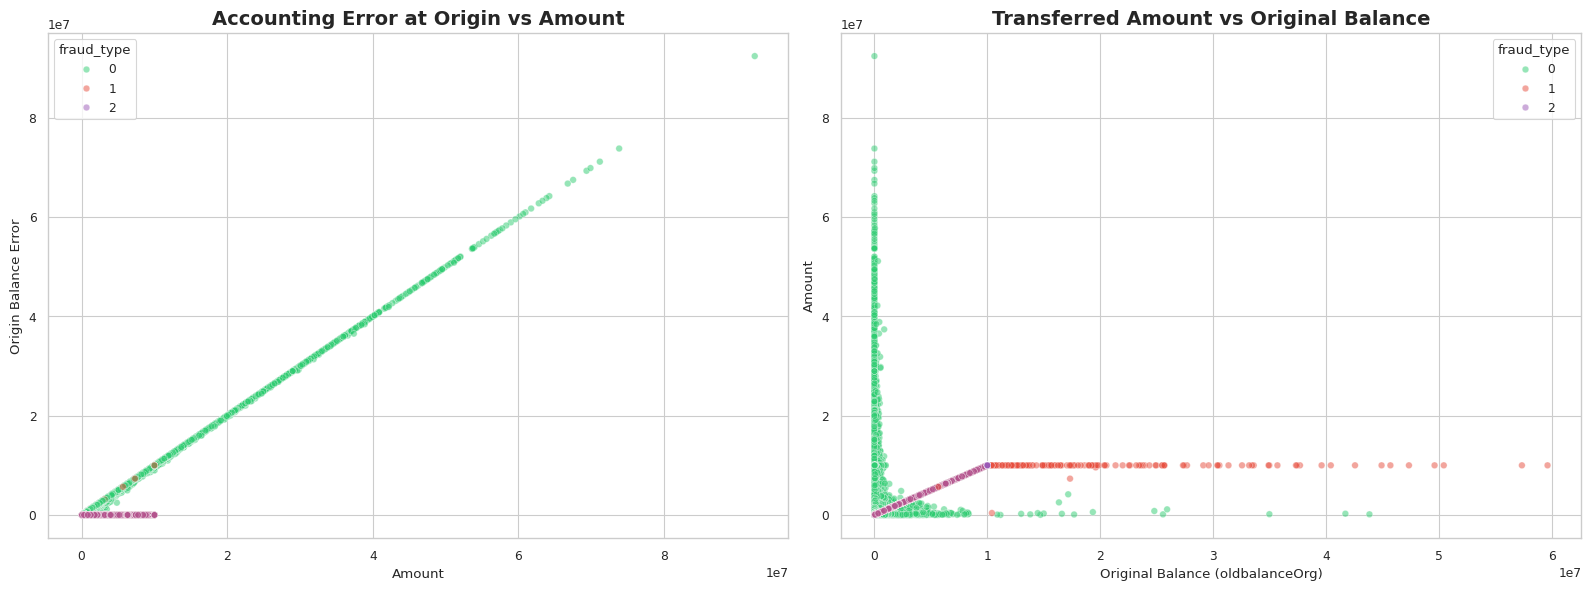

In [6]:
#create accounting error features
df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

#filter only TRANSFER and CASH_OUT to better observe behavior where fraud exists
df_sub = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#subplot 1: Discrepancy at Origin
sns.scatterplot(data=df_sub, x='amount', y='errorBalanceOrg', hue='fraud_type', 
                palette=['#2ecc71', '#e74c3c', '#9b59b6'], alpha=0.5, ax=axes[0])
axes[0].set_title('Accounting Error at Origin vs Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Origin Balance Error')

#subplot 2: Amount vs Old Balance
sns.scatterplot(data=df_sub, x='oldbalanceOrg', y='amount', hue='fraud_type', 
                palette=['#2ecc71', '#e74c3c', '#9b59b6'], alpha=0.5, ax=axes[1])
axes[1].set_title('Transferred Amount vs Original Balance')
axes[1].set_xlabel('Original Balance (oldbalanceOrg)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.show()

In [ ]:
#derive the hour of the day (0-23) from the step variable
df['hour_of_day'] = df['step'] % 24

#group frauds and normal transactions by hour
fraud_by_hour = df[df['fraud_type'] > 0].groupby('hour_of_day')['fraud_type'].count()
normal_by_hour = df[df['fraud_type'] == 0].groupby('hour_of_day')['fraud_type'].count()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

#legitimate transactions
sns.barplot(x=normal_by_hour.index, y=normal_by_hour.values, color='#3498db', ax=axes[0])
axes[0].set_title('Volume of Legitimate Transactions by Hour of Day (0-23)')
axes[0].set_ylabel('Nº Transactions')

#frauds
sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, color='#e74c3c', ax=axes[1])
axes[1].set_title('Volume of Frauds (Class 1 & 2) by Hour of Day')
axes[1].set_ylabel('Nº Frauds')
axes[1].set_xlabel('Hour of the day')

plt.tight_layout()
plt.show()

#drop non-predictive variables to clean the dataset before modeling
cols_to_drop = ['isFlaggedFraud', 'nameOrig', 'nameDest', 'isFraud']
df_model = df.drop(columns=cols_to_drop)

print(f"Final features ready for the modeling phase: {list(df_model.columns)}")